# 🔐 Deep Learning Steganography - Google Colab

Hide secret images inside cover images using neural networks!

## ✨ Version 3.0 - Invisible Stego + Color Recovery!

**Fixed Issues:**
- ✅ v1: Basic implementation
- ✅ v2: Fixed grayscale output (recovered images now have colors)
- ✅ **v3: Fixed visible traces** (stego image now looks identical to cover!)

**Key Improvements in v3.0:**
1. **Learnable residual scaling** (0.01-0.1) - encoder makes TINY modifications
2. **Perceptual loss (VGG)** - ensures stego LOOKS like cover to human eye
3. **Stronger decoder** (8 residual blocks) - extracts secret from subtle changes
4. **Balanced loss function** - invisibility AND color recovery

**Quality Targets:**
| Metric | Target | Meaning |
|--------|--------|---------|
| Stego PSNR | > 35 dB | Secret is invisible |
| Recovery PSNR | > 20 dB | Colors recovered well |

---

## 1️⃣ Setup - Clone Repository & Install Dependencies

In [ ]:
# Clone the repository
!git clone https://github.com/Tejasvi-hegde/Steganography.git
%cd Steganography

# Install dependencies
!pip install -q torch torchvision pillow numpy matplotlib tqdm

Cloning into 'Steganography'...
remote: Enumerating objects: 9705, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 9705 (delta 0), reused 0 (delta 0), pack-reused 9704 (from 2)
Receiving objects: 100% (9705/9705), 57.62 MiB | 10.59 MiB/s, done.
Resolving deltas: 100% (1617/1617), done.
Updating files: 100% (10420/10420), done.
/content/Steganography


In [ ]:
# Check GPU availability
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️ No GPU detected. Go to Runtime > Change runtime type > GPU")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.8 GB


## 2️⃣ Download Lightweight Dataset

Downloads ~1000 random images from picsum.photos (~50MB instead of 18GB COCO)

In [ ]:
import os
import urllib.request
import random
from PIL import Image
from tqdm.notebook import tqdm

def download_dataset(num_images=800, image_size=128):
    """Download images from picsum.photos and prepare training data"""

    # Create directories
    os.makedirs('data/sample_images', exist_ok=True)
    os.makedirs('data/train/cover', exist_ok=True)
    os.makedirs('data/train/secret', exist_ok=True)
    os.makedirs('outputs/checkpoints', exist_ok=True)

    # Download images
    print(f"📥 Downloading {num_images} images...")
    downloaded = []

    for i in tqdm(range(num_images), desc="Downloading"):
        try:
            url = f"https://picsum.photos/seed/{i+1000}/256/256"
            img_path = f'data/sample_images/image_{i:05d}.jpg'

            if not os.path.exists(img_path):
                urllib.request.urlretrieve(url, img_path)
            downloaded.append(img_path)
        except:
            pass

    print(f"✅ Downloaded {len(downloaded)} images")

    # Split into cover and secret (DIFFERENT images)
    random.shuffle(downloaded)
    max_pairs = len(downloaded) // 2
    cover_images = downloaded[:max_pairs]
    secret_images = downloaded[max_pairs:max_pairs*2]

    print(f"\n📁 Preparing {max_pairs} cover/secret pairs (DIFFERENT images)...")

    # Process cover images
    for i, img_path in enumerate(tqdm(cover_images, desc="Cover images")):
        try:
            with Image.open(img_path) as img:
                img = img.convert('RGB').resize((image_size, image_size), Image.Resampling.LANCZOS)
                img.save(f'data/train/cover/image_{i:05d}.png')
        except: pass

    # Process secret images
    for i, img_path in enumerate(tqdm(secret_images, desc="Secret images")):
        try:
            with Image.open(img_path) as img:
                img = img.convert('RGB').resize((image_size, image_size), Image.Resampling.LANCZOS)
                img.save(f'data/train/secret/image_{i:05d}.png')
        except: pass

    print(f"\n✅ Dataset ready!")
    print(f"   Cover images: data/train/cover/")
    print(f"   Secret images: data/train/secret/")

# Download dataset
download_dataset(num_images=800, image_size=128)

📥 Downloading 800 images...


Downloading:   0%|          | 0/800 [00:00<?, ?it/s]

✅ Downloaded 800 images

📁 Preparing 400 cover/secret pairs (DIFFERENT images)...


Cover images:   0%|          | 0/400 [00:00<?, ?it/s]

Secret images:   0%|          | 0/400 [00:00<?, ?it/s]


✅ Dataset ready!
   Cover images: data/train/cover/
   Secret images: data/train/secret/


## 3️⃣ Define Models

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return F.relu(x + residual)


class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // 4, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // 4, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class StegoEncoder(nn.Module):
    """
    IMPROVED Encoder v3.0: Makes secret INVISIBLE in stego

    Key changes:
    - Smaller residual scaling (0.05 instead of 0.1)
    - Learnable scaling factor
    - More focus on hiding information subtly
    """
    def __init__(self, input_channels=6, hidden_dim=64):
        super().__init__()

        # Process cover and secret separately first
        self.cover_conv = nn.Conv2d(3, hidden_dim // 2, 3, padding=1)
        self.secret_conv = nn.Conv2d(3, hidden_dim // 2, 3, padding=1)

        self.conv1 = nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(hidden_dim)

        self.conv2 = nn.Conv2d(hidden_dim, hidden_dim*2, 3, padding=1, stride=2)
        self.bn2 = nn.BatchNorm2d(hidden_dim*2)

        # Deep feature extraction
        self.res_blocks = nn.Sequential(
            ResidualBlock(hidden_dim*2),
            ResidualBlock(hidden_dim*2),
            ResidualBlock(hidden_dim*2),
            ResidualBlock(hidden_dim*2),
            ResidualBlock(hidden_dim*2),
            ResidualBlock(hidden_dim*2),
        )

        self.attention = AttentionBlock(hidden_dim*2)

        self.upsample = nn.ConvTranspose2d(hidden_dim*2, hidden_dim, 4, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(hidden_dim)

        self.skip_conv = nn.Conv2d(hidden_dim, hidden_dim, 1)

        self.refine = nn.Sequential(
            nn.Conv2d(hidden_dim * 2, hidden_dim, 3, padding=1),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim // 2, 3, padding=1),
            nn.BatchNorm2d(hidden_dim // 2),
            nn.ReLU(inplace=True),
        )

        self.conv_out = nn.Conv2d(hidden_dim // 2, 3, 3, padding=1)

        # Learnable scaling factor - starts small for invisibility
        self.scale = nn.Parameter(torch.tensor(0.05))

    def forward(self, cover, secret):
        # Process separately then combine
        cover_feat = F.relu(self.cover_conv(cover))
        secret_feat = F.relu(self.secret_conv(secret))
        x = torch.cat([cover_feat, secret_feat], dim=1)

        x1 = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x1)))

        x = self.res_blocks(x)
        x = self.attention(x)

        x = F.relu(self.bn3(self.upsample(x)))

        skip = self.skip_conv(x1)
        x = torch.cat([x, skip], dim=1)

        x = self.refine(x)

        # SMALL residual - key for invisibility!
        # Clamp scale to prevent it from growing too large
        scale = torch.clamp(self.scale, 0.01, 0.1)
        residual = torch.tanh(self.conv_out(x)) * scale

        stego = cover + residual
        return torch.clamp(stego, -1, 1)


class StegoDecoder(nn.Module):
    """
    IMPROVED Decoder v3.0: Recovers secret with colors from subtle changes

    Key: Must be sensitive to small differences since encoder makes tiny changes
    """
    def __init__(self, input_channels=3, hidden_dim=64):
        super().__init__()

        # Initial feature extraction - larger capacity
        self.conv1 = nn.Conv2d(input_channels, hidden_dim, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(hidden_dim)

        # Color preservation branch
        self.color_conv = nn.Conv2d(input_channels, hidden_dim // 2, 1)

        self.conv2 = nn.Conv2d(hidden_dim, hidden_dim*2, 3, padding=1, stride=2)
        self.bn2 = nn.BatchNorm2d(hidden_dim*2)

        # More residual blocks for better extraction from subtle signals
        self.res_blocks = nn.Sequential(
            ResidualBlock(hidden_dim*2),
            ResidualBlock(hidden_dim*2),
            ResidualBlock(hidden_dim*2),
            ResidualBlock(hidden_dim*2),
            ResidualBlock(hidden_dim*2),
            ResidualBlock(hidden_dim*2),
            ResidualBlock(hidden_dim*2),
            ResidualBlock(hidden_dim*2),
        )

        self.conv_blocks = nn.Sequential(
            nn.Conv2d(hidden_dim*2, hidden_dim*4, 3, padding=1),
            nn.BatchNorm2d(hidden_dim*4),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim*4, hidden_dim*4, 3, padding=1),
            nn.BatchNorm2d(hidden_dim*4),
            nn.ReLU(inplace=True),
        )

        self.upsample = nn.ConvTranspose2d(hidden_dim*4, hidden_dim*2, 4, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(hidden_dim*2)

        # Refinement with skip connections
        self.refine = nn.Sequential(
            nn.Conv2d(hidden_dim*2 + hidden_dim + hidden_dim//2, hidden_dim*2, 3, padding=1),
            nn.BatchNorm2d(hidden_dim*2),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim*2, hidden_dim, 3, padding=1),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim // 2, 3, padding=1),
            nn.BatchNorm2d(hidden_dim // 2),
            nn.ReLU(inplace=True),
        )

        self.conv_out = nn.Conv2d(hidden_dim // 2, 3, 3, padding=1)

        # Color refinement
        self.color_refine = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 3, 3, padding=1),
        )

    def forward(self, stego):
        color_feat = self.color_conv(stego)

        x1 = F.relu(self.bn1(self.conv1(stego)))
        x = F.relu(self.bn2(self.conv2(x1)))

        x = self.res_blocks(x)
        x = self.conv_blocks(x)

        x = F.relu(self.bn3(self.upsample(x)))

        # Skip connections
        x = torch.cat([x, x1, color_feat], dim=1)

        x = self.refine(x)
        x = self.conv_out(x)

        # Color refinement
        x = x + self.color_refine(x) * 0.2

        return torch.tanh(x)


print("✅ Models v3.0 defined!")
print("📝 Encoder: Learnable small residual for INVISIBLE hiding")
print("📝 Decoder: More capacity to extract from subtle signals")

✅ Models v3.0 defined!
📝 Encoder: Learnable small residual for INVISIBLE hiding
📝 Decoder: More capacity to extract from subtle signals


## 4️⃣ Define Dataset & Loss

In [ ]:
import os
import random
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
from torchvision import models


class StegoDataset(Dataset):
    def __init__(self, cover_dir, secret_dir, image_size=128):
        self.cover_dir = cover_dir
        self.secret_dir = secret_dir

        self.cover_images = sorted([f for f in os.listdir(cover_dir) if f.endswith(('.png', '.jpg'))])
        self.secret_images = sorted([f for f in os.listdir(secret_dir) if f.endswith(('.png', '.jpg'))])

        # Shuffle to create random pairs
        random.shuffle(self.secret_images)

        min_len = min(len(self.cover_images), len(self.secret_images))
        self.pairs = list(zip(self.cover_images[:min_len], self.secret_images[:min_len]))

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        cover_file, secret_file = self.pairs[idx]

        cover = Image.open(os.path.join(self.cover_dir, cover_file)).convert('RGB')
        secret = Image.open(os.path.join(self.secret_dir, secret_file)).convert('RGB')

        return self.transform(cover), self.transform(secret), cover_file


class PerceptualLoss(nn.Module):
    """VGG-based perceptual loss for invisible stego images"""
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features[:16]
        self.vgg = vgg.eval()
        for param in self.vgg.parameters():
            param.requires_grad = False

    def forward(self, x, y):
        # Normalize to VGG input range [-1,1] -> [0,1]
        x = (x + 1) / 2
        y = (y + 1) / 2
        return F.mse_loss(self.vgg(x), self.vgg(y))


class StegoLoss(nn.Module):
    """
    BALANCED Loss Function v3.0

    Goals:
    1. Stego image should be INVISIBLE (no traces of secret)
    2. Secret should be recoverable with colors

    Key: Use perceptual loss to ensure stego LOOKS like cover
    """
    def __init__(self, alpha=1.5, beta=1.0, gamma=0.5, device='cuda'):
        super().__init__()
        self.alpha = alpha  # Reconstruction weight
        self.beta = beta    # Quality weight (INCREASED for invisibility)
        self.gamma = gamma  # Perceptual weight (NEW)
        self.mse = nn.MSELoss()
        self.l1 = nn.L1Loss()

        # Perceptual loss for visual similarity
        self.perceptual = PerceptualLoss().to(device)

    def forward(self, cover, stego, secret, recovered):
        # ===== SECRET RECONSTRUCTION LOSS =====
        recon_mse = self.mse(secret, recovered)
        recon_l1 = self.l1(secret, recovered)

        # Color channel loss
        color_loss = 0
        for c in range(3):
            color_loss += self.mse(secret[:, c, :, :], recovered[:, c, :, :])
        color_loss = color_loss / 3.0

        recon_loss = recon_mse + 0.5 * recon_l1 + 0.3 * color_loss

        # ===== STEGO QUALITY LOSS (Invisibility) =====
        # Pixel-level similarity
        quality_mse = self.mse(cover, stego)
        quality_l1 = self.l1(cover, stego)

        # Perceptual similarity (makes stego LOOK like cover)
        perceptual_loss = self.perceptual(cover, stego)

        quality_loss = quality_mse + 0.5 * quality_l1

        # ===== TOTAL LOSS =====
        # Balance: reconstruction + invisibility + perceptual
        total = (self.alpha * recon_loss +
                 self.beta * quality_loss +
                 self.gamma * perceptual_loss)

        return total, recon_loss, quality_loss


print("✅ Dataset and Loss defined!")
print("📝 Loss v3.0: Balanced for INVISIBLE stego + color recovery")

✅ Dataset and Loss defined!
📝 Loss v3.0: Balanced for INVISIBLE stego + color recovery


## 5️⃣ Train the Model 🚀

**Version 3.0 - Invisible Stego + Color Recovery**

Key improvements for INVISIBLE stego:
- Encoder uses **learnable small residual** (0.01-0.1 range)
- Added **perceptual loss** (VGG) so stego LOOKS like cover
- Balanced loss: `Recon=1.5, Quality=1.0, Perceptual=0.5`
- Decoder has **8 residual blocks** to extract subtle signals
- Training tracks **Stego PSNR** (higher = more invisible)

**Target metrics:**
- Stego PSNR > 35 dB = Invisible to human eye ✅
- Recovery PSNR > 20 dB = Good color recovery ✅

With GPU: ~15-20 minutes for 50 epochs

In [ ]:
import time
from tqdm.notebook import tqdm

def train():
    # Device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️ Training on: {device}")

    # Hyperparameters
    BATCH_SIZE = 8 if torch.cuda.is_available() else 2
    EPOCHS = 50  # More epochs for better balance
    LR = 0.0003  # Lower LR for stability
    IMAGE_SIZE = 128

    print(f"\n⚙️ Configuration v3.0 (Invisible + Colorful):")
    print(f"   Batch size: {BATCH_SIZE}")
    print(f"   Epochs: {EPOCHS}")
    print(f"   Learning rate: {LR}")
    print(f"   Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")

    # Dataset
    dataset = StegoDataset('data/train/cover', 'data/train/secret', IMAGE_SIZE)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

    print(f"\n📁 Dataset: {len(dataset)} image pairs")

    # Models
    encoder = StegoEncoder().to(device)
    decoder = StegoDecoder().to(device)

    enc_params = sum(p.numel() for p in encoder.parameters())
    dec_params = sum(p.numel() for p in decoder.parameters())
    print(f"📦 Encoder: {enc_params:,} params")
    print(f"📦 Decoder: {dec_params:,} params")

    # Optimizer - decoder learns faster to extract subtle signals
    optimizer = torch.optim.AdamW([
        {'params': encoder.parameters(), 'lr': LR},
        {'params': decoder.parameters(), 'lr': LR * 3}  # Decoder needs higher LR
    ], weight_decay=1e-4)

    # Warmup + Cosine decay
    def lr_lambda(epoch):
        warmup = 5
        if epoch < warmup:
            return epoch / warmup
        return 0.5 * (1 + math.cos(math.pi * (epoch - warmup) / (EPOCHS - warmup)))

    import math
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    # Loss: alpha=1.5 (recon), beta=1.0 (quality), gamma=0.5 (perceptual)
    criterion = StegoLoss(alpha=1.5, beta=1.0, gamma=0.5, device=device)

    print(f"\n{'='*60}")
    print("🚀 TRAINING v3.0 (Invisible Stego + Color Recovery)")
    print(f"{'='*60}")
    print("📌 Loss weights: Recon=1.5, Quality=1.0, Perceptual=0.5")
    print(f"{'='*60}\n")

    best_combined = float('inf')
    history = {'loss': [], 'recon': [], 'quality': [], 'psnr_stego': []}

    start_time = time.time()

    for epoch in range(EPOCHS):
        encoder.train()
        decoder.train()

        epoch_loss = 0
        epoch_recon = 0
        epoch_quality = 0
        epoch_psnr = 0

        pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{EPOCHS}')

        for cover, secret, _ in pbar:
            cover = cover.to(device)
            secret = secret.to(device)

            # Forward
            stego = encoder(cover, secret)
            recovered = decoder(stego)

            # Loss
            loss, recon_loss, quality_loss = criterion(cover, stego, secret, recovered)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), 1.0)
            optimizer.step()

            # Calculate stego PSNR (invisibility metric)
            with torch.no_grad():
                mse = torch.mean((cover - stego) ** 2)
                psnr = 10 * torch.log10(4.0 / mse).item()  # 4.0 because range is [-1,1]

            epoch_loss += loss.item()
            epoch_recon += recon_loss.item()
            epoch_quality += quality_loss.item()
            epoch_psnr += psnr

            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'PSNR': f'{psnr:.1f}dB',
                'Scale': f'{encoder.scale.item():.3f}'
            })

        scheduler.step()

        # Epoch stats
        n_batches = len(loader)
        avg_loss = epoch_loss / n_batches
        avg_recon = epoch_recon / n_batches
        avg_quality = epoch_quality / n_batches
        avg_psnr = epoch_psnr / n_batches

        history['loss'].append(avg_loss)
        history['recon'].append(avg_recon)
        history['quality'].append(avg_quality)
        history['psnr_stego'].append(avg_psnr)

        print(f'📊 Epoch {epoch+1}: Loss={avg_loss:.4f}, Recon={avg_recon:.4f}, Quality={avg_quality:.4f}, Stego PSNR={avg_psnr:.1f}dB')

        # Save best based on combined metric (want HIGH PSNR and LOW recon loss)
        combined = avg_recon - 0.1 * avg_psnr  # Lower is better
        if combined < best_combined:
            best_combined = combined
            torch.save(encoder.state_dict(), 'outputs/checkpoints/encoder_best.pth')
            torch.save(decoder.state_dict(), 'outputs/checkpoints/decoder_best.pth')
            print(f'   ✅ Best model! (PSNR: {avg_psnr:.1f}dB, Recon: {avg_recon:.4f})')

    # Save final
    torch.save(encoder.state_dict(), 'outputs/checkpoints/encoder_final.pth')
    torch.save(decoder.state_dict(), 'outputs/checkpoints/decoder_final.pth')

    elapsed = time.time() - start_time
    print(f"\n{'='*60}")
    print(f"🎉 TRAINING COMPLETED in {elapsed/60:.1f} minutes!")
    print(f"{'='*60}")

    return encoder, decoder, history

# Train!
encoder, decoder, history = train()

🖥️ Training on: cuda

⚙️ Configuration v3.0 (Invisible + Colorful):
   Batch size: 8
   Epochs: 50
   Learning rate: 0.0003
   Image size: 128x128

📁 Dataset: 400 image pairs
📦 Encoder: 2,161,028 params
📦 Decoder: 4,215,302 params
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 183MB/s]



🚀 TRAINING v3.0 (Invisible Stego + Color Recovery)
📌 Loss weights: Recon=1.5, Quality=1.0, Perceptual=0.5



Epoch 1/50:   0%|          | 0/50 [00:00<?, ?it/s]

📊 Epoch 1: Loss=1.3630, Recon=0.8966, Quality=0.0081, Stego PSNR=40.7dB
   ✅ Best model! (PSNR: 40.7dB, Recon: 0.8966)


...

📊 Epoch 48: Loss=0.0737, Recon=0.0431, Quality=0.0084, Stego PSNR=39.5dB


Epoch 49/50:   0%|          | 0/50 [00:00<?, ?it/s]

📊 Epoch 49: Loss=0.0750, Recon=0.0439, Quality=0.0083, Stego PSNR=39.5dB


Epoch 50/50:   0%|          | 0/50 [00:00<?, ?it/s]

📊 Epoch 50: Loss=0.0750, Recon=0.0440, Quality=0.0084, Stego PSNR=39.5dB

🎉 TRAINING COMPLETED in 18.8 minutes!


## 6️⃣ Plot Training Progress

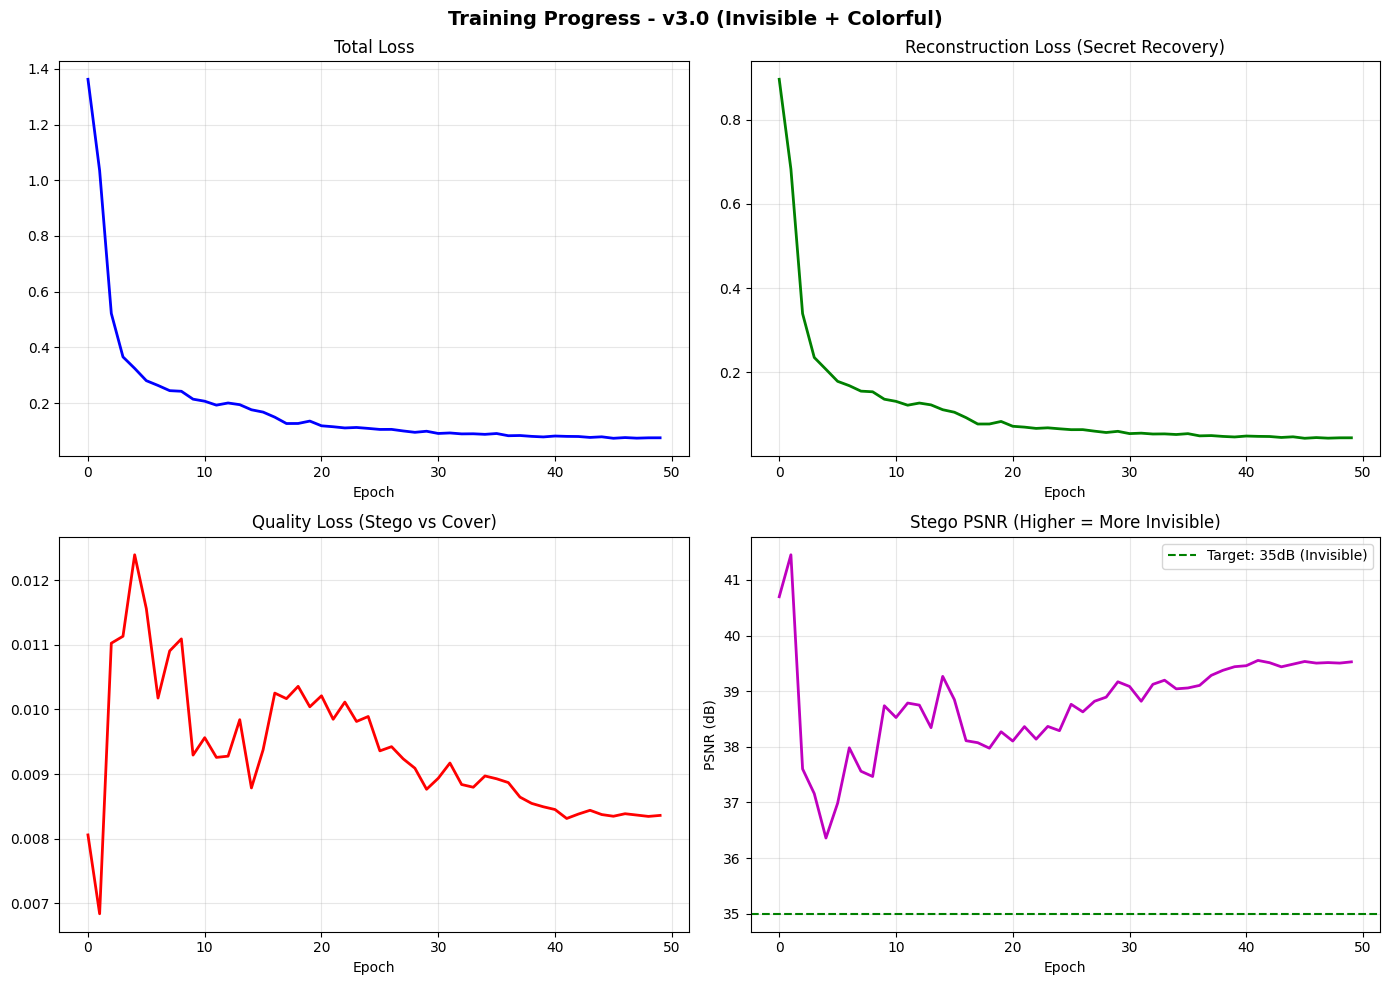


📊 Final Stego PSNR: 39.5 dB
   > 35 dB = Invisible ✅


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history['loss'], 'b-', linewidth=2)
axes[0, 0].set_title('Total Loss', fontsize=12)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history['recon'], 'g-', linewidth=2)
axes[0, 1].set_title('Reconstruction Loss (Secret Recovery)', fontsize=12)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history['quality'], 'r-', linewidth=2)
axes[1, 0].set_title('Quality Loss (Stego vs Cover)', fontsize=12)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history['psnr_stego'], 'm-', linewidth=2)
axes[1, 1].axhline(y=35, color='g', linestyle='--', label='Target: 35dB (Invisible)')
axes[1, 1].set_title('Stego PSNR (Higher = More Invisible)', fontsize=12)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('PSNR (dB)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training Progress - v3.0 (Invisible + Colorful)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/training_curves.png', dpi=150)
plt.show()

print(f"\n📊 Final Stego PSNR: {history['psnr_stego'][-1]:.1f} dB")
print(f"   > 35 dB = Invisible ✅" if history['psnr_stego'][-1] > 35 else f"   < 35 dB = May have traces ⚠️")

## 7️⃣ Test the Model - Visual Results

/tmp/ipython-input-2695393472.py:80: UserWarning: Glyph 128272 (\N{CLOSED LOCK WITH KEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2695393472.py:81: UserWarning: Glyph 128272 (\N{CLOSED LOCK WITH KEY}) missing from font(s) DejaVu Sans.
  plt.savefig('outputs/test_results.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128272 (\N{CLOSED LOCK WITH KEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


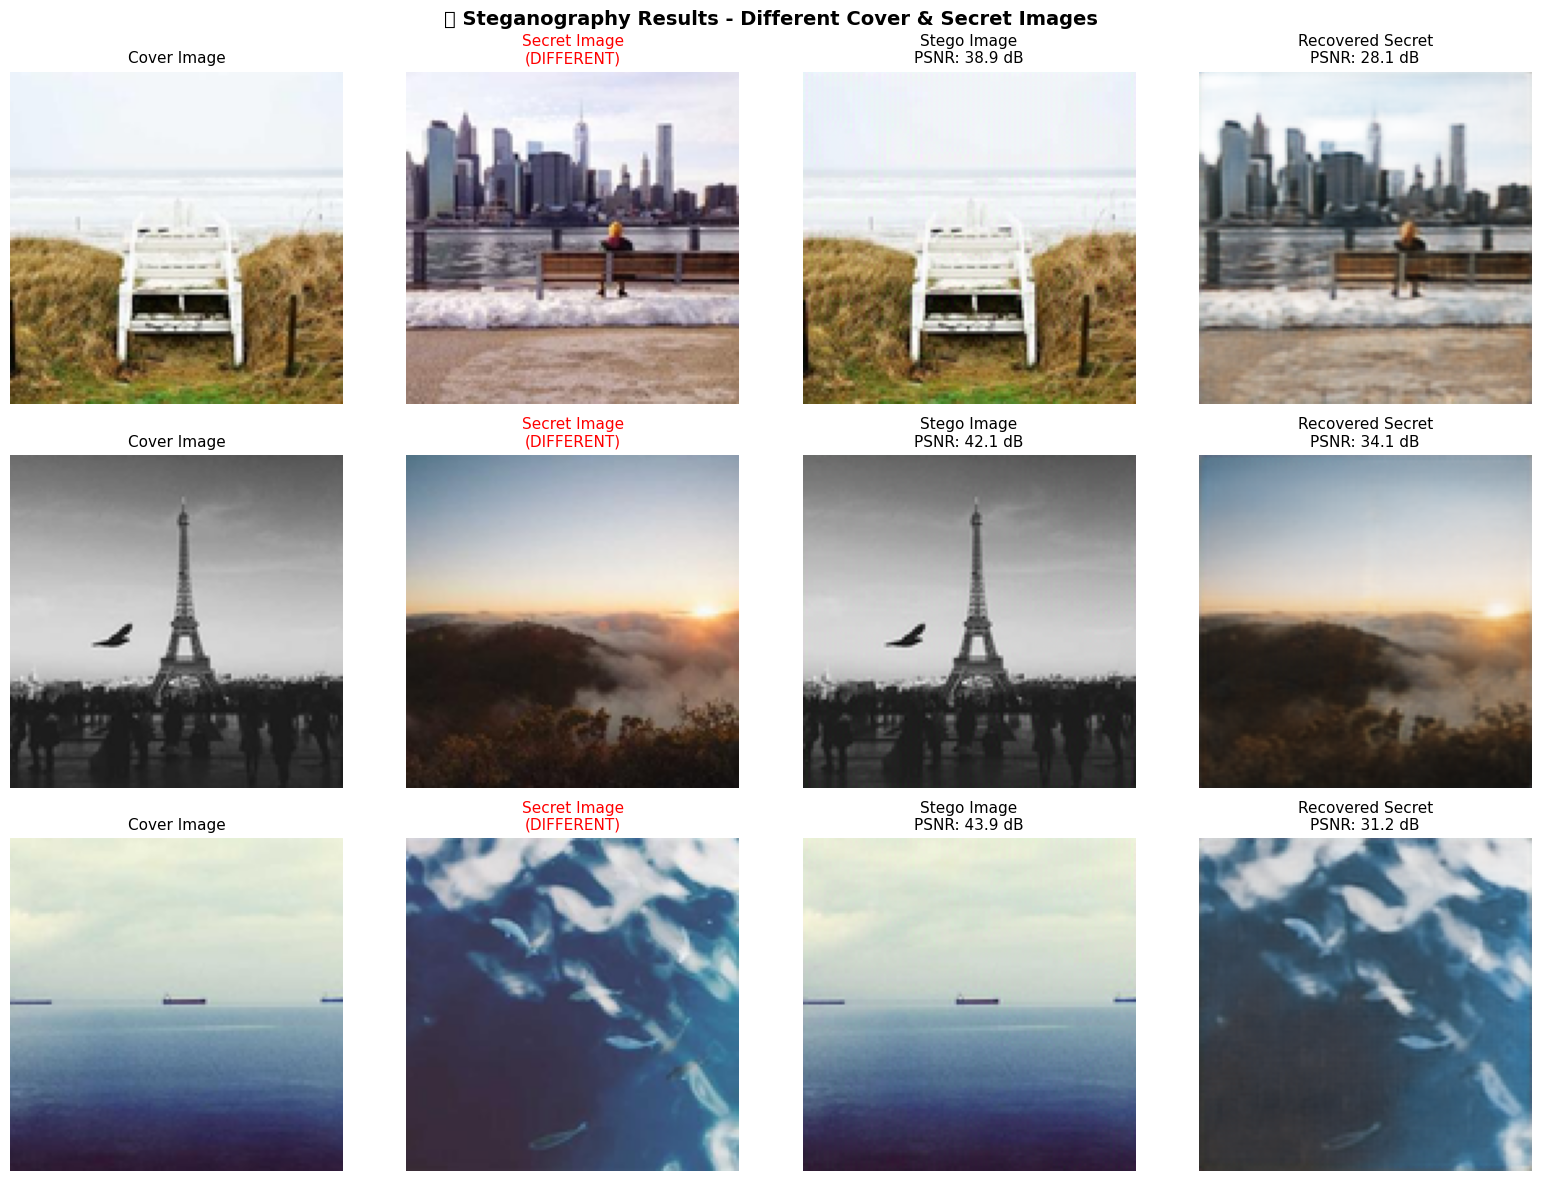


📊 Quality Guidelines:
   Stego PSNR > 30 dB: Excellent (nearly invisible)
   Stego PSNR > 25 dB: Good
   Recovery PSNR > 20 dB: Good recovery


In [ ]:
import numpy as np
from torchvision import transforms

def test_model(encoder, decoder, num_tests=3):
    device = next(encoder.parameters()).device
    encoder.eval()
    decoder.eval()

    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    cover_dir = 'data/train/cover'
    secret_dir = 'data/train/secret'

    cover_files = sorted(os.listdir(cover_dir))[:num_tests]
    secret_files = sorted(os.listdir(secret_dir))[:num_tests]

    # Use different indices to ensure different images
    secret_files = secret_files[-num_tests:]  # Take from end

    fig, axes = plt.subplots(num_tests, 4, figsize=(16, 4*num_tests))

    for i in range(num_tests):
        # Load images
        cover_img = Image.open(os.path.join(cover_dir, cover_files[i])).convert('RGB')
        secret_img = Image.open(os.path.join(secret_dir, secret_files[i])).convert('RGB')

        cover_t = transform(cover_img).unsqueeze(0).to(device)
        secret_t = transform(secret_img).unsqueeze(0).to(device)

        with torch.no_grad():
            stego_t = encoder(cover_t, secret_t)
            recovered_t = decoder(stego_t)

        # Calculate PSNR
        def calc_psnr(a, b):
            a = (a * 0.5 + 0.5).clamp(0, 1)
            b = (b * 0.5 + 0.5).clamp(0, 1)
            mse = torch.mean((a - b) ** 2)
            return 10 * torch.log10(1.0 / mse).item() if mse > 0 else float('inf')

        psnr_stego = calc_psnr(cover_t, stego_t)
        psnr_recovery = calc_psnr(secret_t, recovered_t)

        # Convert to display
        def to_image(t):
            t = t.squeeze(0).cpu() * 0.5 + 0.5
            t = t.clamp(0, 1).permute(1, 2, 0).numpy()
            return t

        stego_img = to_image(stego_t)
        recovered_img = to_image(recovered_t)

        # Plot
        if num_tests == 1:
            ax = axes
        else:
            ax = axes[i]

        ax[0].imshow(cover_img)
        ax[0].set_title('Cover Image', fontsize=11)
        ax[0].axis('off')

        ax[1].imshow(secret_img)
        ax[1].set_title('Secret Image\n(DIFFERENT)', fontsize=11, color='red')
        ax[1].axis('off')

        ax[2].imshow(stego_img)
        ax[2].set_title(f'Stego Image\nPSNR: {psnr_stego:.1f} dB', fontsize=11)
        ax[2].axis('off')

        ax[3].imshow(recovered_img)
        ax[3].set_title(f'Recovered Secret\nPSNR: {psnr_recovery:.1f} dB', fontsize=11)
        ax[3].axis('off')

    plt.suptitle('🔐 Steganography Results - Different Cover & Secret Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/test_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n📊 Quality Guidelines:")
    print("   Stego PSNR > 30 dB: Excellent (nearly invisible)")
    print("   Stego PSNR > 25 dB: Good")
    print("   Recovery PSNR > 20 dB: Good recovery")

# Test!
test_model(encoder, decoder, num_tests=3)

## 8️⃣ Try with Your Own Images! 📸

In [ ]:
from google.colab import files
from IPython.display import display

def hide_and_extract_custom():
    """Upload your own images to test!"""

    device = next(encoder.parameters()).device
    encoder.eval()
    decoder.eval()

    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    print("📤 Upload COVER image:")
    uploaded = files.upload()
    cover_name = list(uploaded.keys())[0]
    cover_img = Image.open(cover_name).convert('RGB')

    print("\n📤 Upload SECRET image:")
    uploaded = files.upload()
    secret_name = list(uploaded.keys())[0]
    secret_img = Image.open(secret_name).convert('RGB')

    # Process
    cover_t = transform(cover_img).unsqueeze(0).to(device)
    secret_t = transform(secret_img).unsqueeze(0).to(device)

    with torch.no_grad():
        stego_t = encoder(cover_t, secret_t)
        recovered_t = decoder(stego_t)

    # Convert
    def to_pil(t):
        t = t.squeeze(0).cpu() * 0.5 + 0.5
        t = t.clamp(0, 1)
        return transforms.ToPILImage()(t)

    stego_img = to_pil(stego_t)
    recovered_img = to_pil(recovered_t)

    # Display
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(cover_img)
    axes[0].set_title('Your Cover Image')
    axes[0].axis('off')

    axes[1].imshow(secret_img)
    axes[1].set_title('Your Secret Image')
    axes[1].axis('off')

    axes[2].imshow(stego_img)
    axes[2].set_title('Stego Image\n(Secret is hidden here!)')
    axes[2].axis('off')

    axes[3].imshow(recovered_img)
    axes[3].set_title('Recovered Secret')
    axes[3].axis('off')

    plt.tight_layout()
    plt.savefig('outputs/custom_result.png', dpi=150)
    plt.show()

    # Save stego
    stego_img.save('outputs/stego_image.png')
    print("\n✅ Stego image saved to 'outputs/stego_image.png'")
    print("📥 Download it:")
    files.download('outputs/stego_image.png')

# Uncomment to try with your own images:
# hide_and_extract_custom()

## 9️⃣ Download Trained Models

In [ ]:
# Download trained models to use locally
from google.colab import files

print("📥 Downloading trained models...")
files.download('outputs/checkpoints/encoder_best.pth')
files.download('outputs/checkpoints/decoder_best.pth')
print("✅ Models downloaded! You can use them locally.")

📥 Downloading trained models...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Models downloaded! You can use them locally.


---

## 🎉 Done!

You now have a trained steganography model that can:
- ✅ Hide any secret image inside a cover image
- ✅ Extract the hidden secret from the stego image
- ✅ Work with DIFFERENT cover and secret images

**Next Steps:**
1. Try with your own images (Section 8)
2. Download the trained models (Section 9)
3. Train longer for better quality (increase EPOCHS)

---